# Projet Data-Driven Decision Making
## Analyse des transactions e-commerce et du comportement client

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Définition du Problème & KPIs

# Problème Métier

L’objectif de ce projet est d’analyser le comportement des clients et les transactions d’un site e-commerce afin d’aider à la prise de décision basée sur les données.

Questions métier principales :
- Comment identifier les clients les plus rentables ?
- Comment améliorer les performances des ventes ?
- Comment segmenter les clients selon leurs comportements d’achat ?
- Comment optimiser les campagnes marketing ?

# KPIs

KPIs principaux :
- Chiffre d’affaires total
- Nombre de commandes
- Valeur moyenne du panier
- Segmentation des clients
- Fidélisation des clients
- Taux de réponse aux campagnes marketing

# KPI Tree

Augmenter le chiffre d’affaires

─ Augmenter le nombre de commandes
─ Augmenter la valeur moyenne du panier
─ Améliorer la fidélisation des clients
─ Optimiser les campagnes marketing


# ROI attendu

L’analyse des données permettra d’identifier les clients à forte valeur et d’optimiser les campagnes marketing.

Les bénéfices attendus sont :
- augmentation du chiffre d’affaires,
- amélioration du ciblage marketing,
- réduction des pertes liées aux campagnes inefficaces,
- amélioration de la fidélisation client.

Une amélioration estimée de 10 à 15 % des ventes peut être envisagée grâce aux décisions basées sur les données.

# 2. Collecte & Audit des Données

# Sources des données1/Cartographie des sources

Dataset 1 :
- Nom : Online Retail Dataset
- Type : Transactions e-commerce
- Format : CSV
- Source : Kaggle

Dataset 2 :
- Nom : Customer Personality Analysis
- Type : Données marketing clients
- Format : CSV
- Source : Kaggle

# Limites et biais des données

- Certaines transactions ne possèdent pas de CustomerID.
- La colonne Income contient des valeurs manquantes.
- Les données clients et transactions ne partagent pas la même clé primaire.
- Les datasets proviennent de sources différentes, ce qui peut limiter certaines analyses croisées.

## Chargement des datasets

In [4]:
data_Orders = pd.read_csv(
    r"C:\ENSIAS\2eme annee\S4\P2\DDDM Projet\data\data_Orders.csv",
    encoding='latin1'
)

customers = pd.read_csv(
    r"C:\ENSIAS\2eme annee\S4\P2\DDDM Projet\data\customers.csv",
    sep="\t",
    encoding='latin1'
)

## Aperçu des données

In [5]:
data_Orders.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
customers.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [7]:
data_Orders.shape
customers.shape

(2240, 29)

In [8]:
data_Orders.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [9]:
customers.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [10]:
data_Orders.info()
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB
<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income     

In [11]:
data_Orders.isnull().sum()
customers.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

# Data Dictionary — Orders Dataset

| Colonne | Type | Description |
|---|---|---|
| InvoiceNo | string | Numéro de facture |
| StockCode | string | Code du produit |
| Description | string | Description du produit |
| Quantity | int | Quantité achetée |
| InvoiceDate | datetime | Date de la transaction |
| UnitPrice | float | Prix unitaire |
| CustomerID | float | Identifiant du client |
| Country | string | Pays du client |
| Revenue | float | Revenu généré par la vente |

# Data Dictionary — Customers Dataset

| Colonne | Type | Description |
|---|---|---|
| ID | int | Identifiant client |
| Year_Birth | int | Année de naissance |
| Education | string | Niveau d’éducation |
| Marital_Status | string | Situation familiale |
| Income | float | Revenu annuel du client |
| Kidhome | int | Nombre d’enfants à la maison |
| Teenhome | int | Nombre d’adolescents à la maison |
| Dt_Customer | datetime | Date d’inscription du client |
| Recency | int | Nombre de jours depuis le dernier achat |
| NumWebPurchases | int | Nombre d’achats en ligne |
| NumStorePurchases | int | Nombre d’achats en magasin |
| Response | int | Réponse à la campagne marketing |
| Total_Spending | float | Dépenses totales du client |
| Age | int | Âge du client |

# 3. Préparation et Nettoyage des Données

In [12]:
data_Orders.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [13]:
customers.dtypes

ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [14]:
#Nettoyer et préparer les données avant l’analyse/1. Vérifier les doublons
data_Orders.duplicated().sum()

np.int64(5268)

In [15]:
customers.duplicated().sum()

np.int64(0)

In [16]:
#Nettoyer et préparer les données avant l’analyse/2. Supprimer les doublons
data_Orders = data_Orders.drop_duplicates()

customers = customers.drop_duplicates()

In [17]:
#Nettoyer et préparer les données avant l’analyse/3. Vérification à nouveau
data_Orders.duplicated().sum()

customers.duplicated().sum()

np.int64(0)

In [18]:
#Nettoyer et préparer les données avant l’analyse/4. Traiter les valeurs manquantes (On remplace les valeurs manquantes par la moyenne :)
customers["Income"] = customers["Income"].fillna(customers["Income"].mean())

In [19]:
customers.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [20]:
#5. Nettoyer Orders
data_Orders = data_Orders.dropna(subset=["CustomerID"])

In [21]:
data_Orders.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [22]:
#6. Convertir les dates
data_Orders["InvoiceDate"] = pd.to_datetime(data_Orders["InvoiceDate"])

In [23]:
#6. Convertir les dates
customers["Dt_Customer"] = pd.to_datetime(
    customers["Dt_Customer"],
    dayfirst=True
)

In [24]:
data_Orders.info()

customers.info()

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  str           
 1   StockCode    401604 non-null  str           
 2   Description  401604 non-null  str           
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[us]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 47.3 MB
<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2  

In [25]:
#8. Créer une nouvelle variable : Revenue
data_Orders["Revenue"] = data_Orders["Quantity"] * data_Orders["UnitPrice"]

### Création de la variable Revenue

La variable `Revenue` a été créée afin de calculer le chiffre d’affaires généré par chaque transaction.

Elle est calculée avec la formule :

Revenue = Quantity × UnitPrice

Cette variable sera utilisée pour :
- analyser les ventes,
- identifier les produits rentables,
- calculer les KPIs financiers,
- réaliser les analyses statistiques et prédictives.

In [26]:
data_Orders.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [27]:
#9. Créer l’âge des clients
customers["Age"] = 2026 - customers["Year_Birth"]

### Création de la variable Age

La variable `Age` a été créée à partir de l’année de naissance des clients.

Elle permettra :
- d’analyser les comportements selon l’âge,
- d’identifier les segments de clientèle,
- d’étudier l’impact de l’âge sur les achats.

In [28]:
#10. Créer Total Spending
customers["Total_Spending"] = (
    customers["MntWines"] +
    customers["MntFruits"] +
    customers["MntMeatProducts"] +
    customers["MntFishProducts"] +
    customers["MntSweetProducts"] +
    customers["MntGoldProds"]
)

### Création de la variable Total_Spending

La variable `Total_Spending` représente le montant total dépensé par chaque client.

Elle est calculée à partir de plusieurs catégories de produits :
- vins,
- fruits,
- viande,
- poisson,
- produits sucrés,
- produits premium.

Cette variable permettra :
- d’identifier les clients à forte valeur,
- de segmenter les clients,
- d’analyser les comportements d’achat.

# Gaps de données

- Absence de relation directe entre les deux datasets.
- Données démographiques limitées dans le dataset Orders.
- Plusieurs transactions sans identifiant client.

# 4. Exploration & Analyse Statistique des Données (EDA)

Objectif de cette phase

Comprendre :

les ventes,
les clients,
les produits,
les comportements d’achat,
les relations entre variables.

## 3.1 Statistiques descriptives

In [29]:
data_Orders.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,401604.000000,401604,401604.000000,401604.000000,401604.000000
mean,12.183273,2011-07-10 12:08:23.848567,3.474064,15281.160818,20.613638
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000,-168469.600000
25%,2.000000,2011-04-06 15:02:00,1.250000,13939.000000,4.250000
50%,5.000000,2011-07-29 15:40:00,1.950000,15145.000000,11.700000
75%,12.000000,2011-10-20 11:58:30,3.750000,16784.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,250.283037,NaN,69.764035,1714.006089,430.352218


In [30]:
customers.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142,49.109375,303.935714,26.302232,166.950000,...,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,57.194196,605.798214
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,30.000000,5.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,49.000000,68.750000
50%,5458.500000,1970.000000,51741.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,56.000000,396.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,67.000000,1045.500000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,133.000000,2525.000000
std,3246.662198,11.984069,25037.797168,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,...,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,602.249288


### Interprétation des statistiques descriptives

Le dataset clients contient 2240 clients.

Observations principales :

- L’âge moyen des clients est d’environ 57 ans.
- Le revenu moyen des clients est d’environ 52 247.
- Les dépenses totales moyennes des clients sont de 605.
- Certains clients présentent des revenus très élevés, ce qui indique la présence possible de valeurs aberrantes.
- La variable Recency montre que certains clients ont acheté récemment tandis que d’autres sont inactifs depuis longtemps.
- Les variables liées aux campagnes marketing montrent que peu de clients acceptent les campagnes proposées.

## 3.2 Distribution du chiffre d’affaires

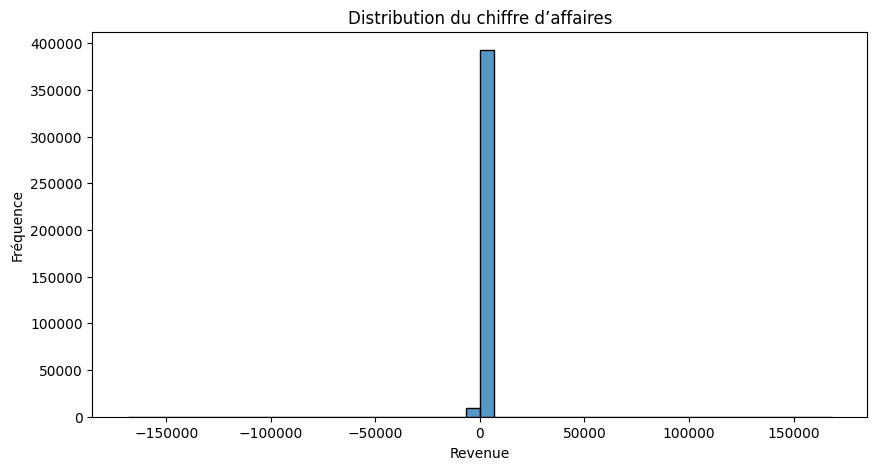

In [31]:
plt.figure(figsize=(10,5))

sns.histplot(data_Orders["Revenue"], bins=50)

plt.title("Distribution du chiffre d’affaires")
plt.xlabel("Revenue")
plt.ylabel("Fréquence")

plt.show()

### Interprétation de la distribution du Revenue

La majorité des transactions génèrent un faible revenu, tandis qu’un petit nombre de transactions présentent des revenus très élevés.

Cela indique une distribution asymétrique avec présence de valeurs extrêmes (outliers).

Ces résultats sont fréquents dans les datasets e-commerce où quelques transactions importantes génèrent une grande partie du chiffre d’affaires.

## 3.2.1 Distribution du Revenue (sans valeurs extrêmes)

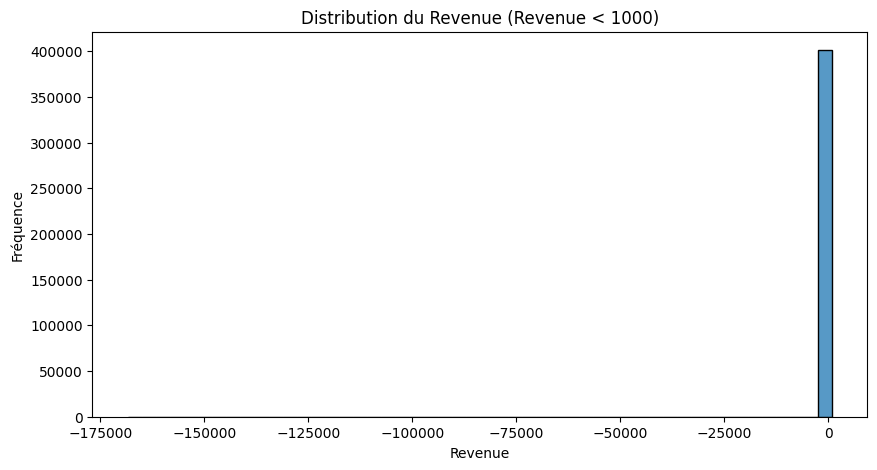

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(
    data_Orders[data_Orders["Revenue"] < 1000]["Revenue"],
    bins=50
)

plt.title("Distribution du Revenue (Revenue < 1000)")
plt.xlabel("Revenue")
plt.ylabel("Fréquence")

plt.show()

### Interprétation de la distribution du Revenue (sans valeurs extrêmes)

Après suppression des valeurs extrêmes, la distribution du chiffre d’affaires montre que la majorité des transactions génèrent de faibles revenus.

La distribution reste asymétrique, avec une forte concentration des ventes autour des petites valeurs de Revenue.

Cela signifie que :
- la majorité des clients effectuent de petits achats,
- seules quelques transactions génèrent des revenus importants,
- le comportement observé est typique des plateformes e-commerce.

Cette analyse confirme également la présence de valeurs aberrantes importantes dans le dataset initial.

## 3.3 Top pays générant le plus de revenu

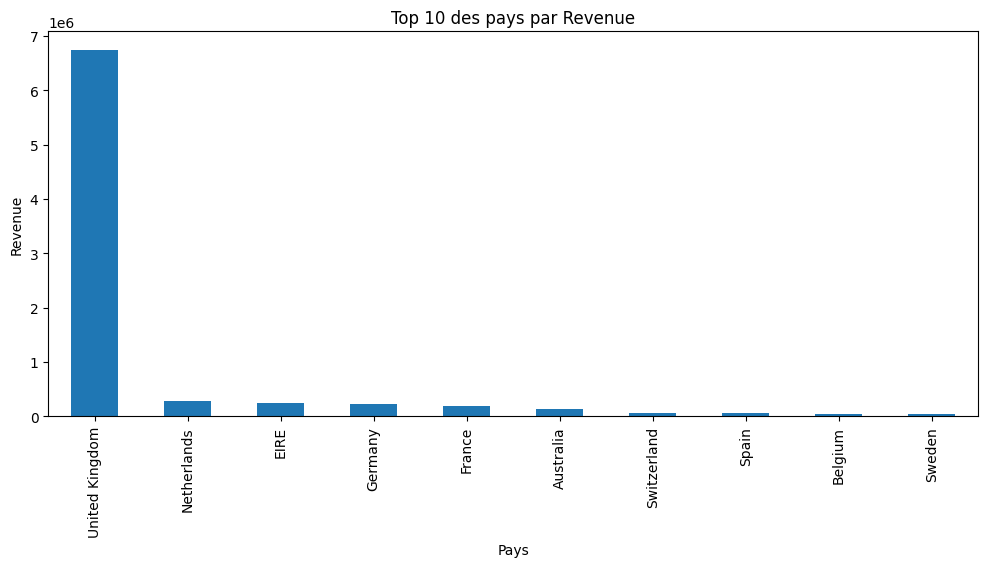

In [33]:
top_countries = (
    data_Orders.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

top_countries.plot(kind="bar")

plt.title("Top 10 des pays par Revenue")
plt.xlabel("Pays")
plt.ylabel("Revenue")

plt.show()

### Interprétation des revenus par pays

Le graphique montre les pays générant le plus de chiffre d’affaires.

On observe qu’un petit nombre de pays contribue fortement aux revenus globaux de l’entreprise.

Ces résultats permettent :
- d’identifier les marchés les plus rentables,
- d’orienter les stratégies marketing,
- de prioriser certains pays pour les campagnes commerciales.

Les pays ayant les revenus les plus élevés représentent des opportunités importantes pour le développement de l’activité.

## 3.4 Produits les plus vendus

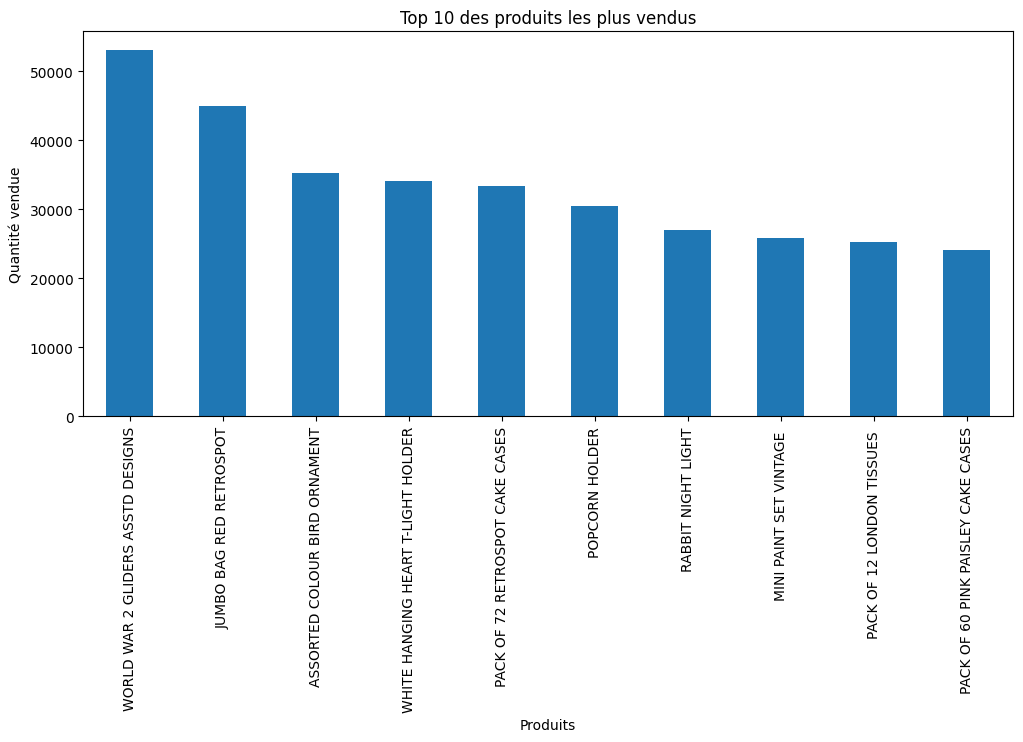

In [35]:
top_products = (
    data_Orders.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

top_products.plot(kind="bar")

plt.title("Top 10 des produits les plus vendus")
plt.xlabel("Produits")
plt.ylabel("Quantité vendue")

plt.show()

### Interprétation des produits les plus vendus

Le graphique met en évidence les produits les plus populaires auprès des clients.

Certains produits présentent des volumes de ventes beaucoup plus élevés que les autres, ce qui montre leur forte demande sur le marché.

Cette analyse permet :
- d’identifier les produits stratégiques,
- d’optimiser la gestion du stock,
- d’améliorer les recommandations marketing,
- de mieux comprendre les préférences des clients.

## 3.5 Corrélations entre les variables

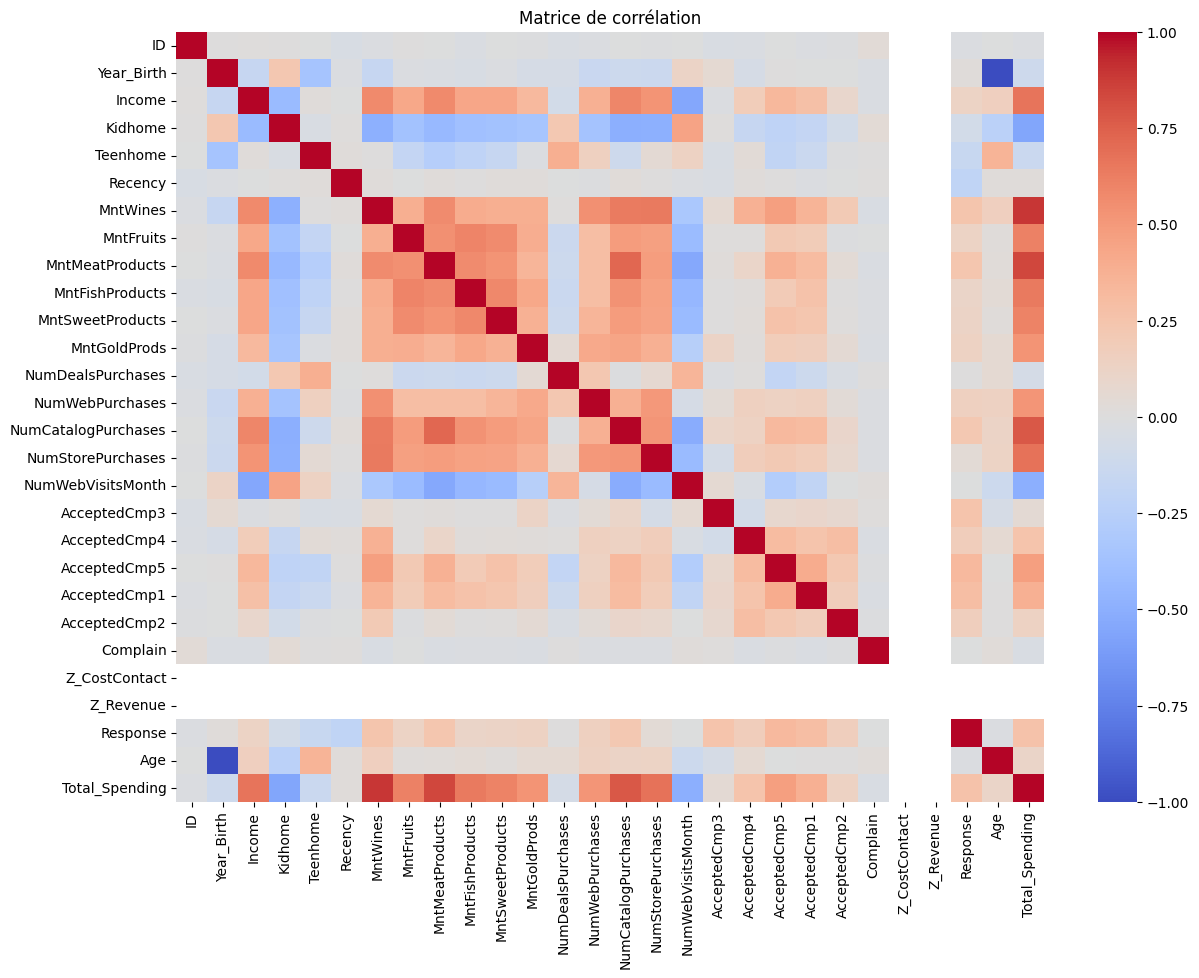

In [36]:
plt.figure(figsize=(14,10))

sns.heatmap(
    customers.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Matrice de corrélation")

plt.show()

### Interprétation de la matrice de corrélation

La matrice de corrélation permet d’identifier les relations entre les variables numériques du dataset clients.

On observe plusieurs corrélations positives entre :
- le revenu des clients,
- les dépenses,
- les achats de produits.

Cela signifie que les clients ayant des revenus élevés ont tendance à dépenser davantage.

Cette analyse est utile pour :
- identifier les variables importantes,
- préparer les modèles de Machine Learning,
- améliorer la segmentation des clients.

## 3.6 Détection des valeurs aberrantes (Outliers)

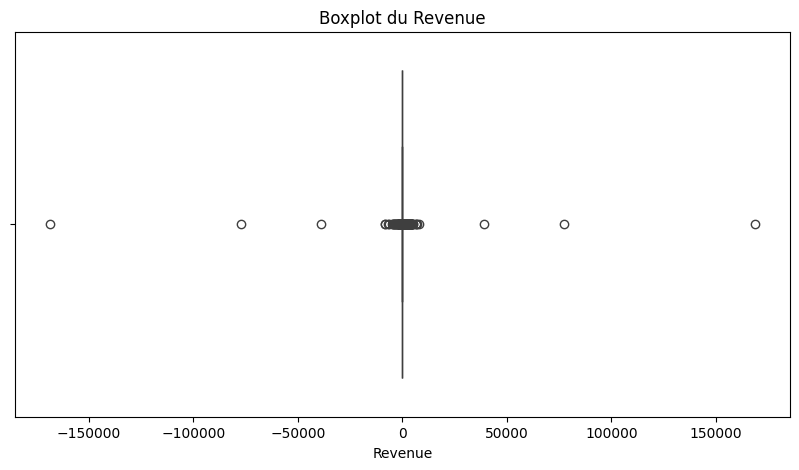

In [37]:
plt.figure(figsize=(10,5))

sns.boxplot(x=data_Orders["Revenue"])

plt.title("Boxplot du Revenue")

plt.show()

### Interprétation des valeurs aberrantes

Le boxplot du Revenue met en évidence plusieurs valeurs aberrantes représentant des transactions exceptionnellement élevées.

Ces valeurs extrêmes peuvent influencer :
- les statistiques descriptives,
- les modèles de Machine Learning,
- les analyses de revenus.

Cependant, dans un contexte e-commerce, ces transactions importantes peuvent correspondre à des achats réels et stratégiques.

Il est donc important d’analyser ces valeurs avant de décider de les supprimer.

## 3.7 Analyse des clients selon l’âge

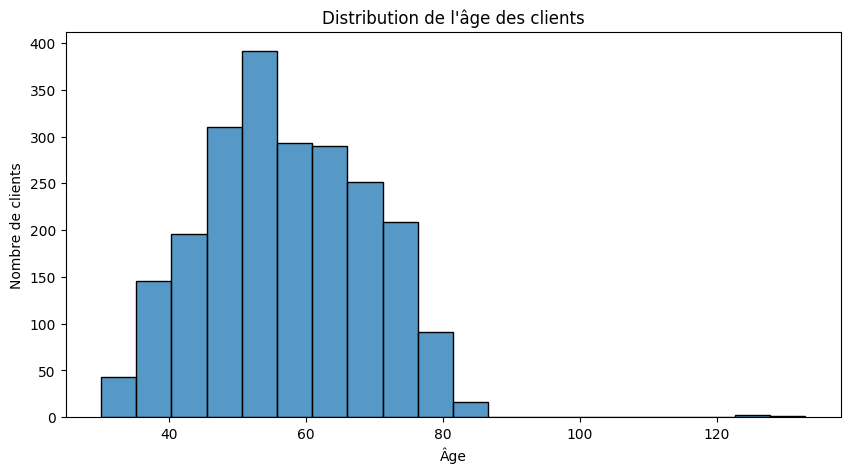

In [38]:
plt.figure(figsize=(10,5))

sns.histplot(customers["Age"], bins=20)

plt.title("Distribution de l'âge des clients")
plt.xlabel("Âge")
plt.ylabel("Nombre de clients")

plt.show()

### Interprétation de la distribution de l’âge

La distribution de l’âge montre que la majorité des clients appartiennent à des tranches d’âge intermédiaires.

On observe une concentration importante de clients adultes, tandis que les clients très jeunes ou très âgés sont moins représentés.

Cette analyse permet :
- de mieux comprendre le profil des clients,
- d’adapter les stratégies marketing,
- d’identifier les segments démographiques les plus importants.

## 3.8 Relation entre Income et Total_Spending

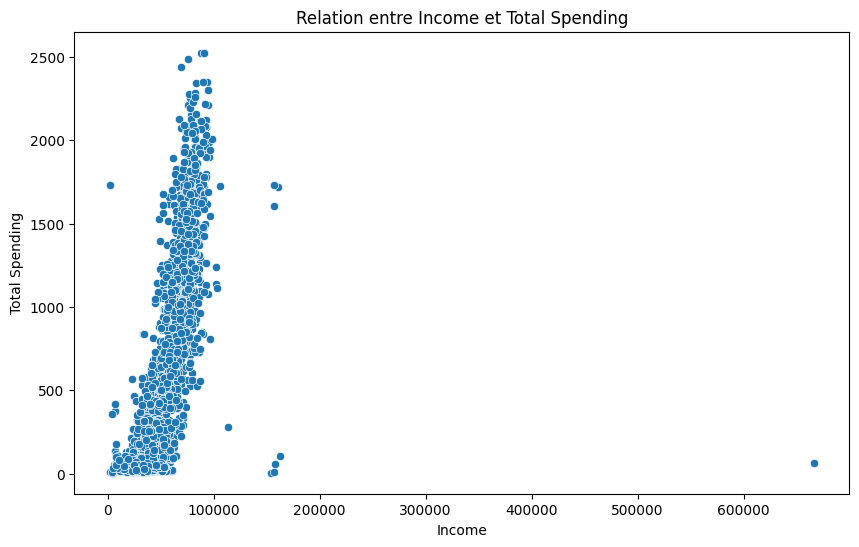

In [39]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=customers["Income"],
    y=customers["Total_Spending"]
)

plt.title("Relation entre Income et Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")

plt.show()

### Interprétation de la relation entre Income et Total Spending

Le graphique montre une corrélation positive entre le revenu des clients et leurs dépenses totales.

Les clients ayant des revenus élevés ont tendance à dépenser davantage.

On observe également quelques clients avec des revenus ou des dépenses exceptionnellement élevés, ce qui peut indiquer des clients VIP ou des valeurs aberrantes.

Cette analyse est particulièrement utile pour :
- la segmentation des clients,
- l’identification des clients à forte valeur,
- les stratégies de ciblage marketing.

## 3.9 Violin Plot des dépenses clients

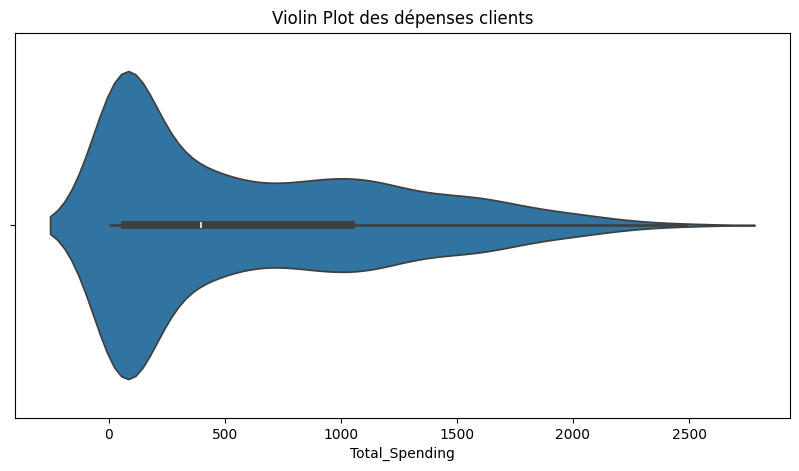

In [56]:
plt.figure(figsize=(10,5))

sns.violinplot(
    x=customers["Total_Spending"]
)

plt.title("Violin Plot des dépenses clients")

plt.show()

### Interprétation du Violin Plot

Le violin plot permet de visualiser la distribution des dépenses des clients ainsi que la densité des données.

On observe une forte concentration des clients autour des dépenses faibles et moyennes, tandis que quelques clients présentent des dépenses élevées.

## 3.10 Scatter Matrix

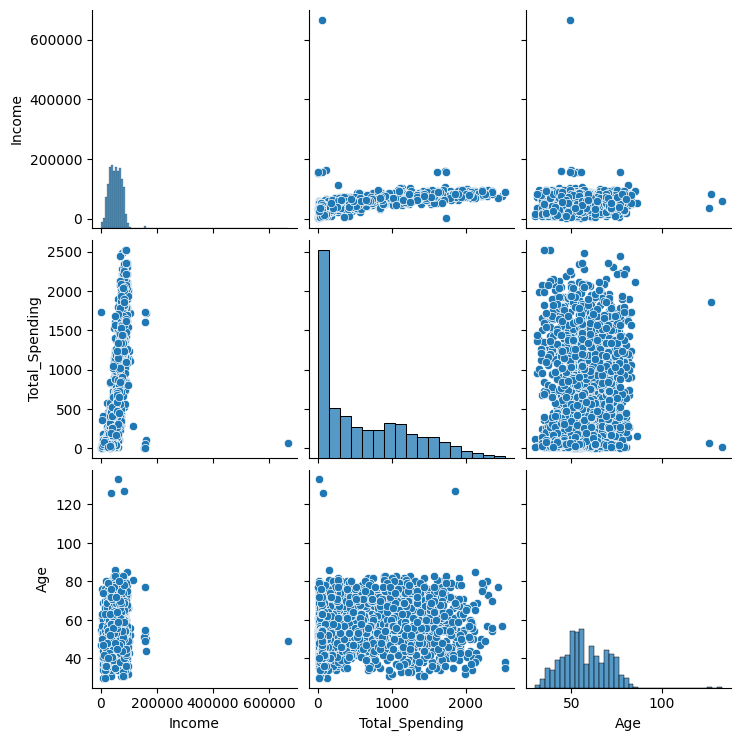

In [57]:
sns.pairplot(
    customers[[
        "Income",
        "Total_Spending",
        "Age"
    ]]
)

plt.show()

### Interprétation de la Scatter Matrix

La scatter matrix permet de visualiser les relations entre plusieurs variables numériques.

On observe une corrélation positive entre le revenu et les dépenses totales des clients.

Cette visualisation aide à identifier les tendances et les regroupements naturels dans les données.

## 3.11 Test statistique — T-Test

In [58]:
from scipy.stats import ttest_ind

high_income = customers[
    customers["Income"] > customers["Income"].median()
]["Total_Spending"]

low_income = customers[
    customers["Income"] <= customers["Income"].median()
]["Total_Spending"]

t_stat, p_value = ttest_ind(
    high_income,
    low_income
)

print("T-statistic :", t_stat)
print("P-value :", p_value)

T-statistic : 52.17884000000082
P-value : 0.0


### Interprétation du T-Test

Le T-Test compare les dépenses des clients à revenu élevé et à revenu faible.

Une p-value faible indique une différence statistiquement significative entre les deux groupes.

Cela signifie que le revenu influence significativement les dépenses des clients.

# 4. Segmentation & Clustering des Clients

## 4.1 Préparation des données pour le clustering

In [40]:
clustering_data = customers[[
    "Income",
    "Total_Spending",
    "Age"
]]

clustering_data.head()

,Income,Total_Spending,Age
0,58138.0,1617,69
1,46344.0,27,72
2,71613.0,776,61
3,26646.0,53,42
4,58293.0,422,45


### Préparation des données de clustering

Les variables sélectionnées pour le clustering sont :
- le revenu des clients,
- les dépenses totales,
- l’âge.

Ces variables permettent d’identifier différents profils de clients selon leur pouvoir d’achat et leur comportement de consommation.

## 4.2 Normalisation des données

In [42]:
#Importer StandardScaler
from sklearn.preprocessing import StandardScaler

In [43]:
#Créer le scaler
scaler = StandardScaler()

In [44]:
#Normaliser les données
scaled_data = scaler.fit_transform(clustering_data)

In [45]:
#Afficher les données normalisées
scaled_data[:5]

array([[ 0.23532677,  1.67941681,  0.98534473],
       [-0.23582624, -0.96127545,  1.23573295],
       [ 0.77363327,  0.28267329,  0.3176428 ],
       [-1.02273246, -0.91809432, -1.26814929],
       [ 0.24151879, -0.30525442, -1.01776106]])

### Interprétation de la normalisation

Les variables ont été normalisées afin de les mettre à la même échelle avant l’application du clustering K-Means.

Cette étape est importante car certaines variables, comme le revenu, possèdent des valeurs beaucoup plus élevées que d’autres variables.

La normalisation permet d’éviter qu’une seule variable domine le modèle de clustering.

## 4.3 Méthode du coude (Elbow Method)

In [46]:
from sklearn.cluster import KMeans

In [47]:
#Créer une liste vide
inertia = []

In [48]:
#Calculer les inertias
for k in range(1, 11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(scaled_data)
    
    inertia.append(kmeans.inertia_)

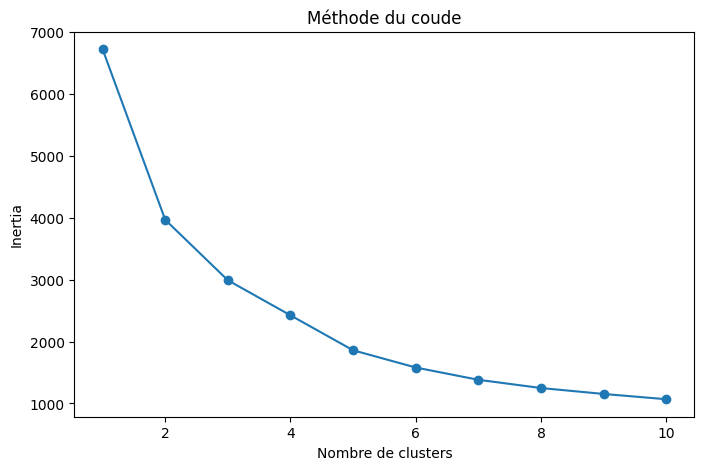

In [49]:
#Tracer le graphique
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title("Méthode du coude")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertia")

plt.show()

### Interprétation de la méthode du coude

La méthode du coude permet d’identifier le nombre optimal de clusters pour le modèle K-Means.

On observe que l’inertie diminue fortement au début puis commence progressivement à se stabiliser.

Le point de stabilisation représente le nombre de clusters le plus pertinent pour segmenter les clients.

## 4.4 Application du K-Means

In [50]:
#Créer le modèle K-Means (coude=4)
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

In [51]:
#Entraîner le modèle
customers["Cluster"] = kmeans.fit_predict(scaled_data)

In [52]:
#Vérifier les clusters
customers[["Income", "Total_Spending", "Age", "Cluster"]].head()

,Income,Total_Spending,Age,Cluster
0,58138.0,1617,69,2
1,46344.0,27,72,1
2,71613.0,776,61,2
3,26646.0,53,42,0
4,58293.0,422,45,0


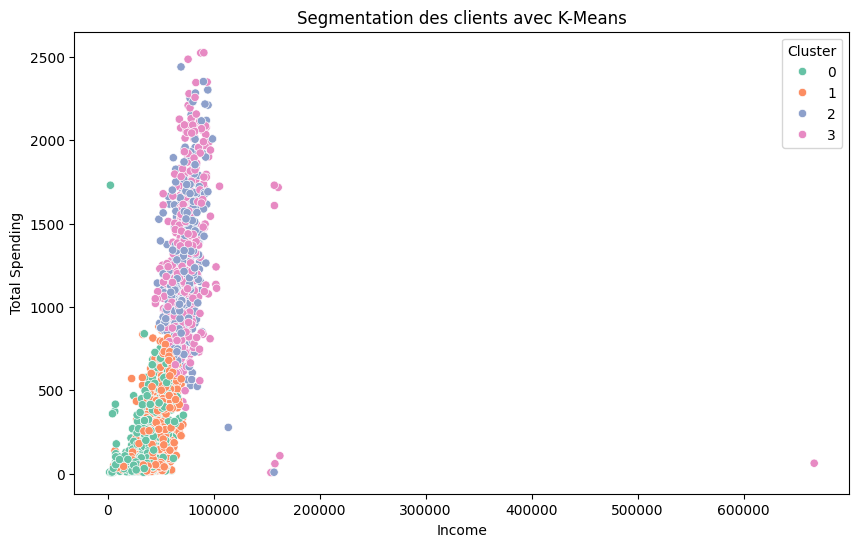

In [53]:
#Visualiser les clusters
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=customers["Income"],
    y=customers["Total_Spending"],
    hue=customers["Cluster"],
    palette="Set2"
)

plt.title("Segmentation des clients avec K-Means")
plt.xlabel("Income")
plt.ylabel("Total Spending")

plt.show()

### Interprétation des clusters clients

Le modèle K-Means a permis de segmenter les clients en plusieurs groupes selon :
- leur revenu,
- leurs dépenses,
- leur âge.

Chaque cluster représente un profil de clients différent.

On peut identifier :
- des clients à forte valeur,
- des clients à faible dépense,
- des profils intermédiaires.

Cette segmentation peut être utilisée pour :
- personnaliser les campagnes marketing,
- améliorer le ciblage commercial,
- optimiser la fidélisation des clients.

## 4.5 Analyse des clusters

In [54]:
#Calculer les moyennes par cluster
cluster_analysis = customers.groupby("Cluster")[[
    "Income",
    "Total_Spending",
    "Age"
]].mean()

cluster_analysis

,Income,Total_Spending,Age
Cluster,,,
0,34405.151820,148.500000,48.609639
1,45710.631345,269.662455,67.779783
2,72409.686121,1250.402948,69.604423
3,75018.118052,1281.572383,48.752784


### Interprétation des clusters

L’analyse des moyennes permet d’identifier différents profils de clients.

Certains clusters présentent :
- des revenus élevés,
- des dépenses importantes,
- un fort potentiel commercial.

D’autres clusters représentent des clients à faible valeur ou des clients occasionnels.

Cette segmentation aide l’entreprise à adapter ses stratégies marketing selon chaque profil client.

In [55]:
#Identifier les clients VIP
vip_customers = customers[
    customers["Cluster"] == customers.groupby("Cluster")["Total_Spending"].mean().idxmax()
]

vip_customers.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending,Cluster
36,4339,1970,PhD,Married,67353.0,0,1,2013-12-31,37,702,...,0,0,0,0,3,11,0,56,913,3
40,8601,1980,Graduation,Married,80011.0,0,1,2013-04-29,3,421,...,0,0,0,0,3,11,0,46,1395,3
45,1371,1976,Graduation,Single,79941.0,0,0,2014-06-28,72,123,...,0,0,0,0,3,11,0,50,984,3
53,2225,1977,Graduation,Divorced,82582.0,0,0,2014-06-07,54,510,...,0,1,0,0,3,11,1,49,1617,3
54,9381,1978,Graduation,Married,66373.0,1,1,2013-06-12,57,328,...,0,0,0,0,3,11,0,48,606,3


### Recommandations Business

À partir de la segmentation des clients, plusieurs recommandations peuvent être proposées :

- cibler les clients VIP avec des offres premium,
- améliorer la fidélisation des clients à forte valeur,
- proposer des promotions personnalisées aux clients à faible dépense,
- optimiser les campagnes marketing selon les profils clients.

Cette approche permet d’améliorer :
- le chiffre d’affaires,
- la satisfaction client,
- la performance marketing.